## Matplotlib Question on Datasets

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:\\Users\\rohit\\Downloads\\matplotlib_sales_clean_1000.csv")

df.head()

,Order_ID,Order_Date,City,Product_Category,Customer_Segment,Customer_Age,Units_Sold,Unit_Price,Discount_Pct,Customer_Rating,Gross_Sales,Discount_Amount,Revenue,Cost,Profit
0,ORD00849,2025-01-01,Pune,Home & Kitchen,Budget,36,5,13359.07,2.33,3.4,66795.35,1556.33,65239.02,45347.81,19891.21
1,ORD00678,2025-01-01,Hyderabad,Home & Kitchen,Premium,42,2,13594.04,19.92,3.9,27188.08,5415.87,21772.21,15198.49,6573.72
2,ORD00649,2025-01-01,Delhi,Home & Kitchen,Budget,25,5,1657.67,2.85,2.7,8288.35,236.22,8052.13,4569.99,3482.14
3,ORD00756,2025-01-01,Bengaluru,Home & Kitchen,Premium,31,3,2487.88,32.94,3.7,7463.64,2458.52,5005.12,3547.03,1458.09
4,ORD00992,2025-01-01,Delhi,Beauty,Regular,43,4,20911.12,26.06,4.2,83644.48,21797.75,61846.73,36979.40,24867.33


#### 1. Plot monthly Revenue as a line chart. Add title, axis labels, markers, grid, and legend.

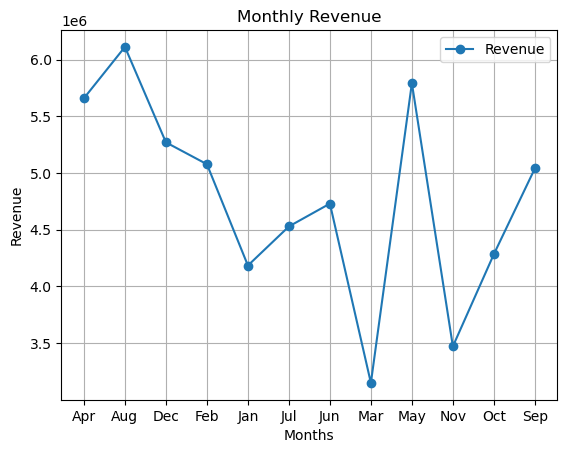

In [3]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

Months = df.groupby(df["Order_Date"].dt.strftime("%b"))["Revenue"].sum()

plt.plot(Months.index, Months.values,
         marker='o',
         label='Revenue')

plt.title("Monthly Revenue")
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.grid(True)
plt.legend()

plt.show()

#### 2. Plot monthly Revenue and Profit on the same chart using different line styles.

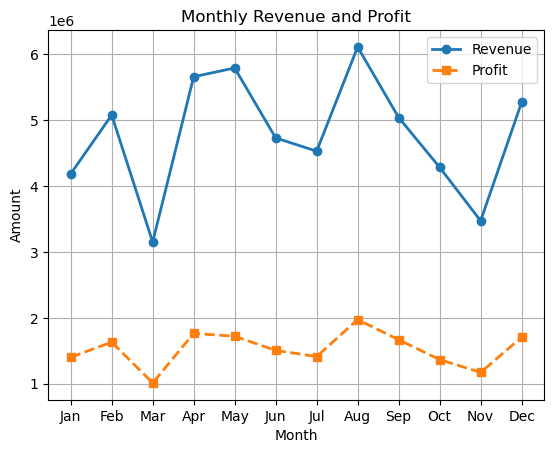

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date into datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month column
df["Month"] = df["Order_Date"].dt.strftime("%b")

# Correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Group Revenue and Profit by Month
monthly_data = (
    df.groupby("Month")[["Revenue", "Profit"]]
      .sum()
      .reindex(month_order)
      .dropna()
)

# Plot Revenue
plt.plot(
    monthly_data.index,
    monthly_data["Revenue"],
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Revenue'
)

# Plot Profit
plt.plot(
    monthly_data.index,
    monthly_data["Profit"],
    marker='s',
    linestyle='--',
    linewidth=2,
    label='Profit'
)

# Title and Labels
plt.title("Monthly Revenue and Profit")
plt.xlabel("Month")
plt.ylabel("Amount")

# Grid and Legend
plt.grid(True)
plt.legend()

# Show Plot
plt.show()

#### 3. Create a bar chart of total Revenue by Product_Category and sort the categories from highest to lowest revenue.

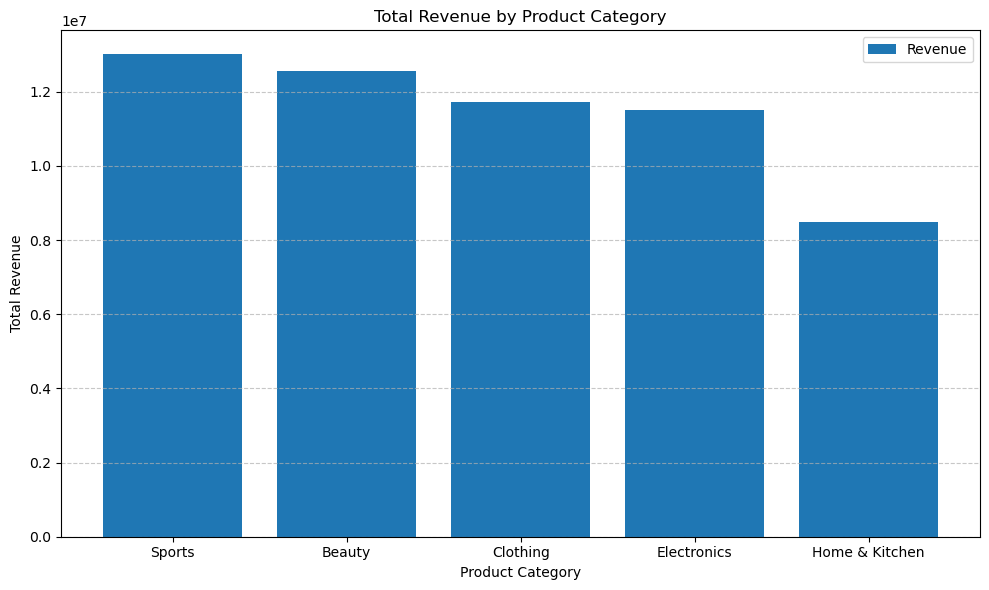

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate total Revenue by Product_Category
category_revenue = (
    df.groupby("Product_Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue.index,
    category_revenue.values,
    label="Revenue"
)

# Title and labels
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

# Grid and legend
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 4. Create a bar chart of total Profit by City and highlight the city with the highest profit.

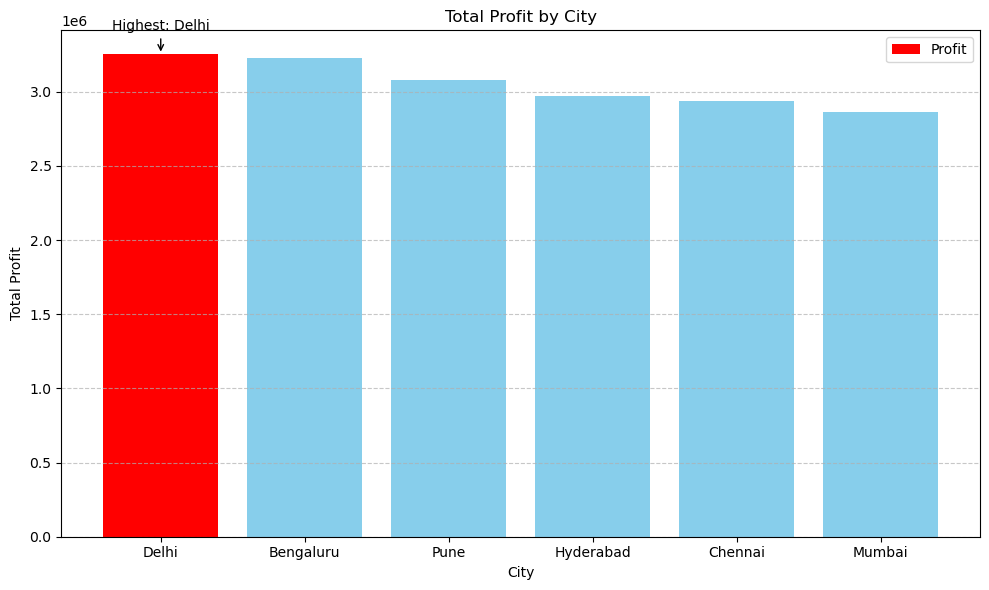

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate total Profit by City
city_profit = (
    df.groupby("City")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

# Find city with highest profit
highest_city = city_profit.idxmax()
highest_profit = city_profit.max()

# Create colors
colors = ["skyblue"] * len(city_profit)
colors[0] = "red"

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    city_profit.index,
    city_profit.values,
    color=colors,
    label="Profit"
)

# Annotate highest-profit city
plt.annotate(
    f"Highest: {highest_city}",
    xy=(0, highest_profit),
    xytext=(0, highest_profit * 1.05),
    ha="center",
    arrowprops=dict(arrowstyle="->")
)

# Title and labels
plt.title("Total Profit by City")
plt.xlabel("City")
plt.ylabel("Total Profit")

# Grid and legend
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 5. Create a horizontal bar chart showing the top 10 orders based on Revenue.

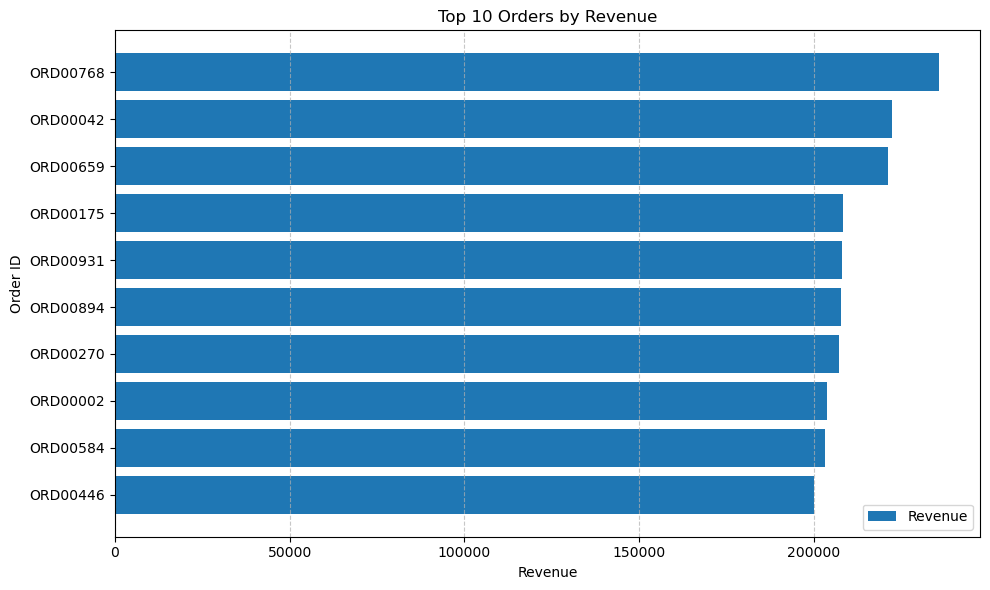

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Select top 10 orders based on Revenue
top_10_orders = (
    df.nlargest(10, "Revenue")
      .sort_values("Revenue")
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_orders["Order_ID"].astype(str),
    top_10_orders["Revenue"],
    label="Revenue"
)

# Title and labels
plt.title("Top 10 Orders by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Order ID")

# Grid and legend
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 6. Create a histogram of Customer_Age using 10 appropriate bins. Add mean and median lines.

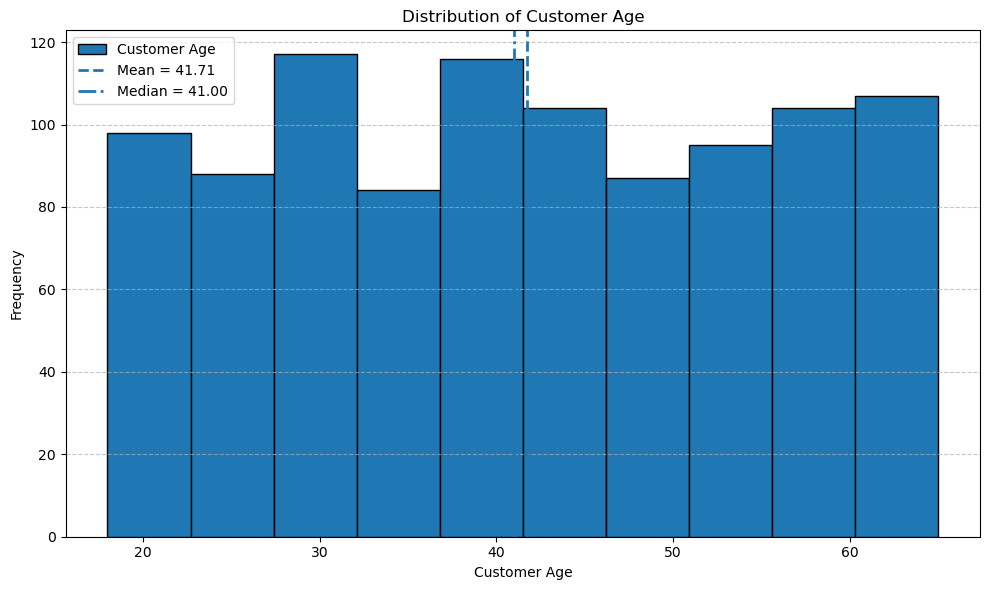

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate mean and median
mean_age = df["Customer_Age"].mean()
median_age = df["Customer_Age"].median()

# Create histogram
plt.figure(figsize=(10, 6))

plt.hist(
    df["Customer_Age"],
    bins=10,
    edgecolor="black",
    label="Customer Age"
)

# Add mean line
plt.axvline(
    mean_age,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_age:.2f}"
)

# Add median line
plt.axvline(
    median_age,
    linestyle="-.",
    linewidth=2,
    label=f"Median = {median_age:.2f}"
)

# Title and labels
plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")

# Grid and legend
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 7. Create a histogram of Revenue and explain visually whether the distribution appears symmetric or skewed.

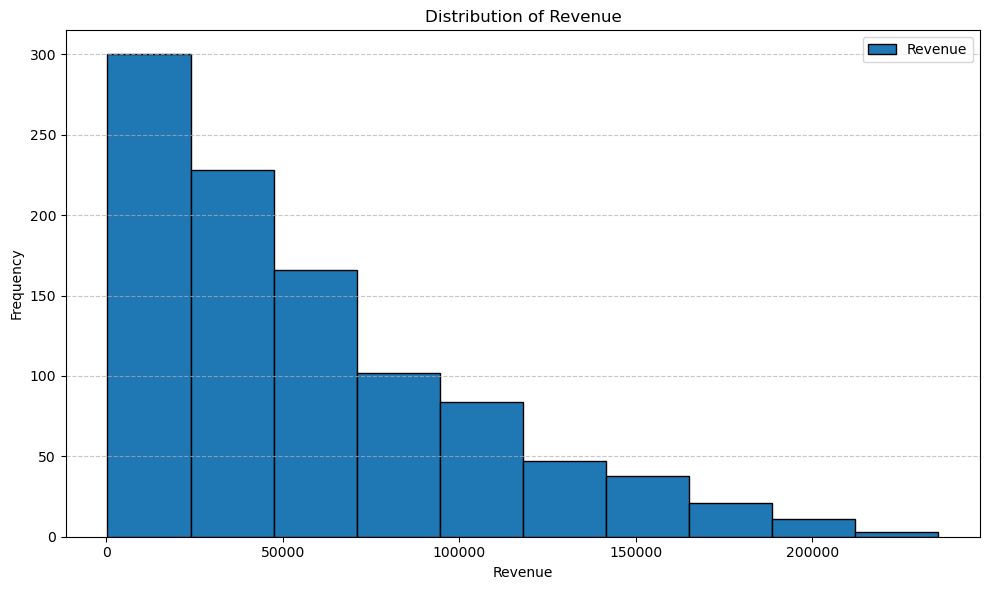

In [9]:
import matplotlib.pyplot as plt

# Create histogram of Revenue
plt.figure(figsize=(10, 6))

plt.hist(
    df["Revenue"],
    bins=10,
    edgecolor="black",
    label="Revenue"
)

# Title and labels
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

# Grid and legend
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 8. Create a scatter plot of Unit_Price vs Units_Sold. Use different marker sizes based on Revenue.

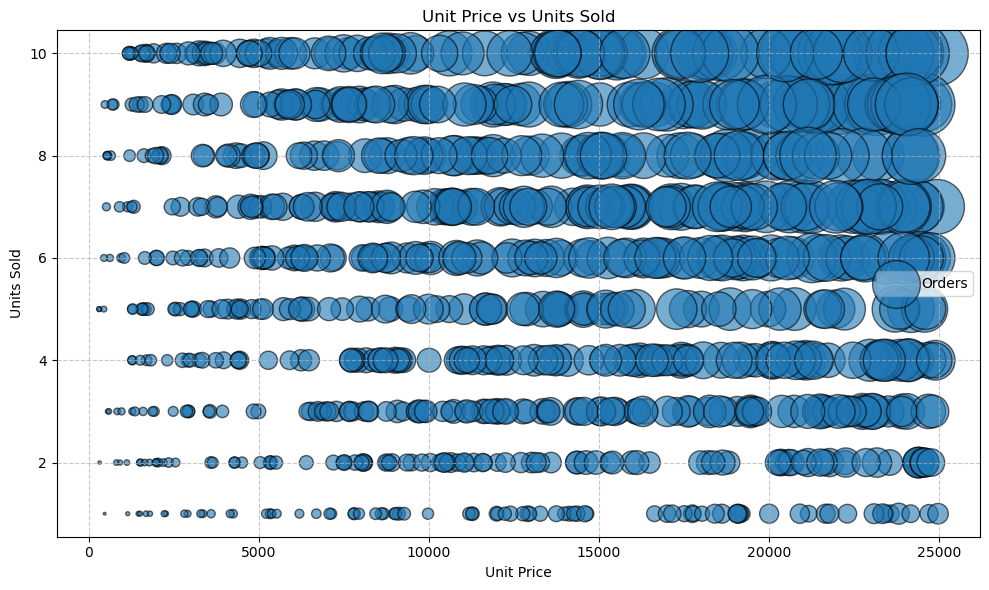

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Unit_Price"],
    df["Units_Sold"],
    s=df["Revenue"] / 100,
    alpha=0.6,
    edgecolor="black",
    label="Orders"
)

# Title and labels
plt.title("Unit Price vs Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 9. Create a scatter plot of Discount_Pct vs Profit and determine visually whether higher discounts are associated with lower profit.

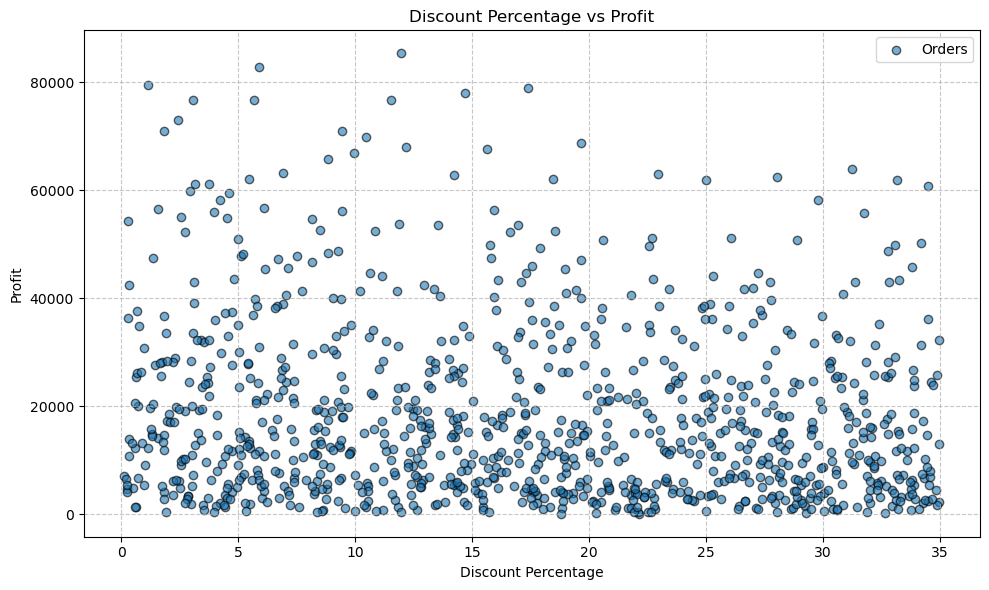

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6,
    edgecolor="black",
    label="Orders"
)

# Title and labels
plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 10. Create a scatter plot of Revenue vs Profit and highlight the five orders having the highest profit.

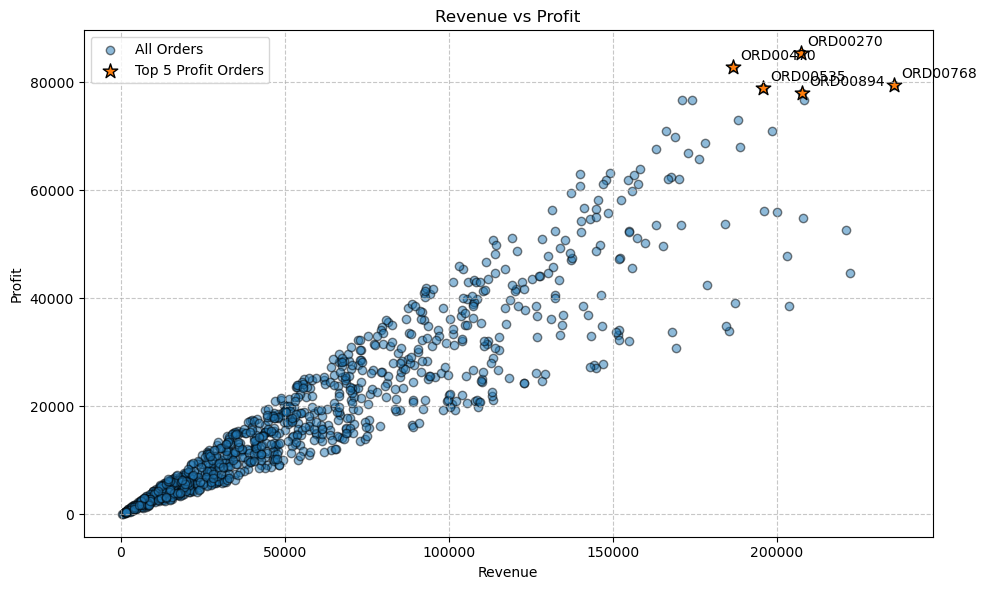

In [12]:
import matplotlib.pyplot as plt

# Find top 5 orders based on Profit
top_5_profit = df.nlargest(5, "Profit")

# Create scatter plot for all orders
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Revenue"],
    df["Profit"],
    alpha=0.5,
    edgecolor="black",
    label="All Orders"
)

# Highlight top 5 profit orders
plt.scatter(
    top_5_profit["Revenue"],
    top_5_profit["Profit"],
    s=120,
    marker="*",
    edgecolor="black",
    label="Top 5 Profit Orders"
)

# Annotate top 5 orders
for _, row in top_5_profit.iterrows():
    plt.annotate(
        str(row["Order_ID"]),
        (row["Revenue"], row["Profit"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Title and labels
plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 11. Create a pie chart of Revenue contribution by Product_Category. Display percentage values.

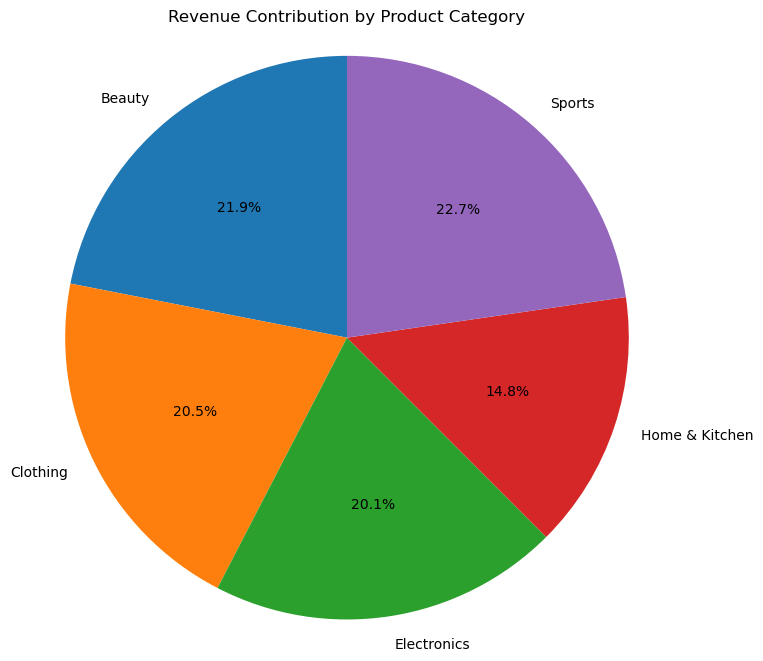

In [13]:
import matplotlib.pyplot as plt

# Calculate total Revenue by Product Category
category_revenue = (
    df.groupby("Product_Category")["Revenue"]
      .sum()
)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

# Title
plt.title("Revenue Contribution by Product Category")

# Keep pie chart circular
plt.axis("equal")

plt.show()

#### 12. Create a 2×2 subplot containing:
##### o Revenue by month
##### o Profit by month
##### o Revenue by category
##### o Profit by city

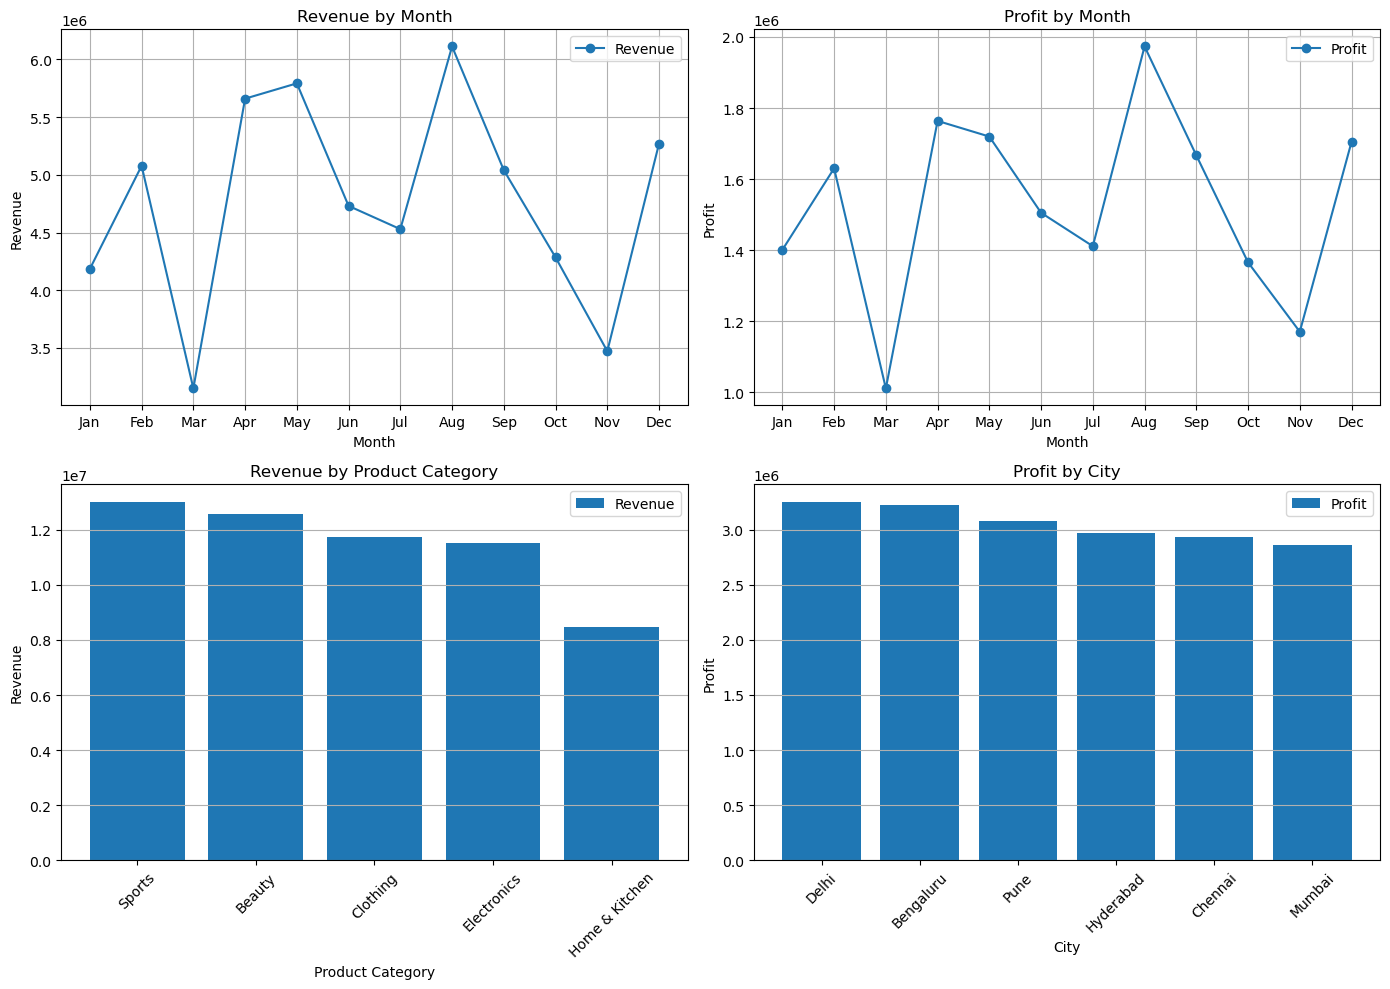

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date into datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month column
df["Month"] = df["Order_Date"].dt.strftime("%b")

# Correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Monthly Revenue
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reindex(month_order)
      .dropna()
)

# Monthly Profit
monthly_profit = (
    df.groupby("Month")["Profit"]
      .sum()
      .reindex(month_order)
      .dropna()
)

# Revenue by Category
category_revenue = (
    df.groupby("Product_Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

# Profit by City
city_profit = (
    df.groupby("City")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

# Create 2×2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Revenue by Month
axes[0, 0].plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    label="Revenue"
)
axes[0, 0].set_title("Revenue by Month")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].grid(True)
axes[0, 0].legend()

# 2. Profit by Month
axes[0, 1].plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="o",
    label="Profit"
)
axes[0, 1].set_title("Profit by Month")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].grid(True)
axes[0, 1].legend()

# 3. Revenue by Category
axes[1, 0].bar(
    category_revenue.index,
    category_revenue.values,
    label="Revenue"
)
axes[1, 0].set_title("Revenue by Product Category")
axes[1, 0].set_xlabel("Product Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(axis="y")
axes[1, 0].legend()

# 4. Profit by City
axes[1, 1].bar(
    city_profit.index,
    city_profit.values,
    label="Profit"
)
axes[1, 1].set_title("Profit by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y")
axes[1, 1].legend()

# Adjust spacing
plt.tight_layout()

# Display
plt.show()

#### 13. Create a stacked bar chart showing Revenue by month for each Product_Category.

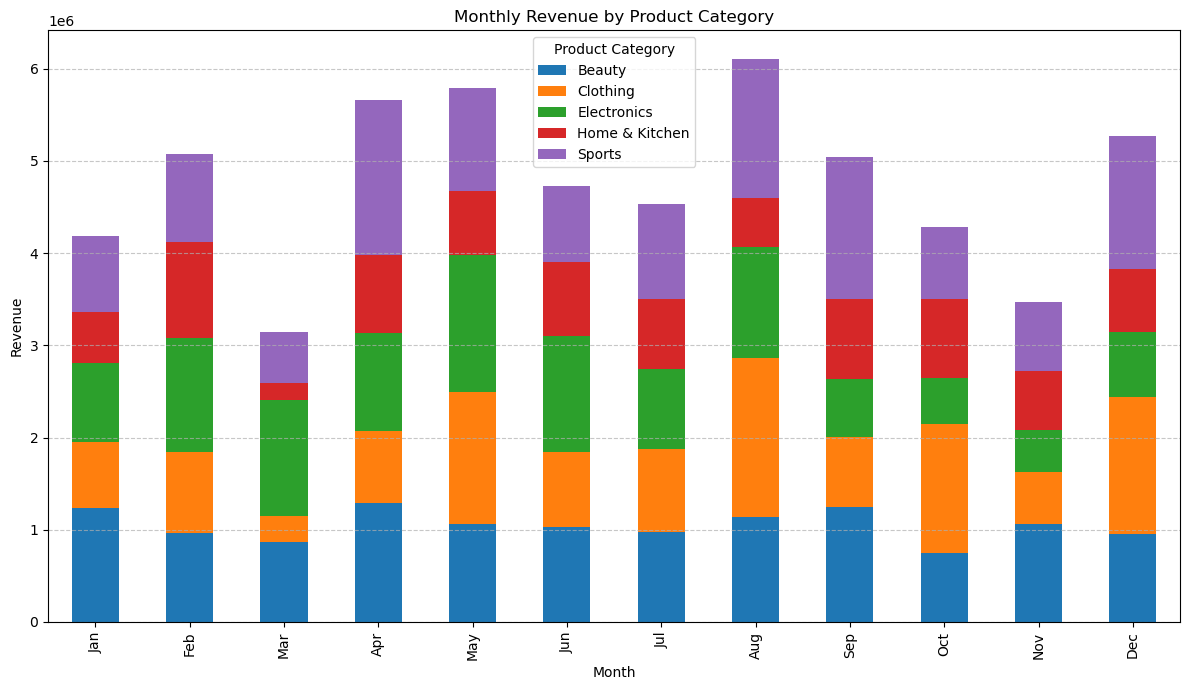

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date into datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month column
df["Month"] = df["Order_Date"].dt.strftime("%b")

# Correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Calculate monthly Revenue for each Product Category
monthly_category_revenue = (
    df.groupby(["Month", "Product_Category"])["Revenue"]
      .sum()
      .unstack(fill_value=0)
      .reindex(month_order)
)

# Create stacked bar chart
monthly_category_revenue.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

# Title and labels
plt.title("Monthly Revenue by Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue")

# Grid and legend
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Product Category")

plt.tight_layout()
plt.show()

#### 14. Create a grouped bar chart comparing Revenue across cities for different customer segments.

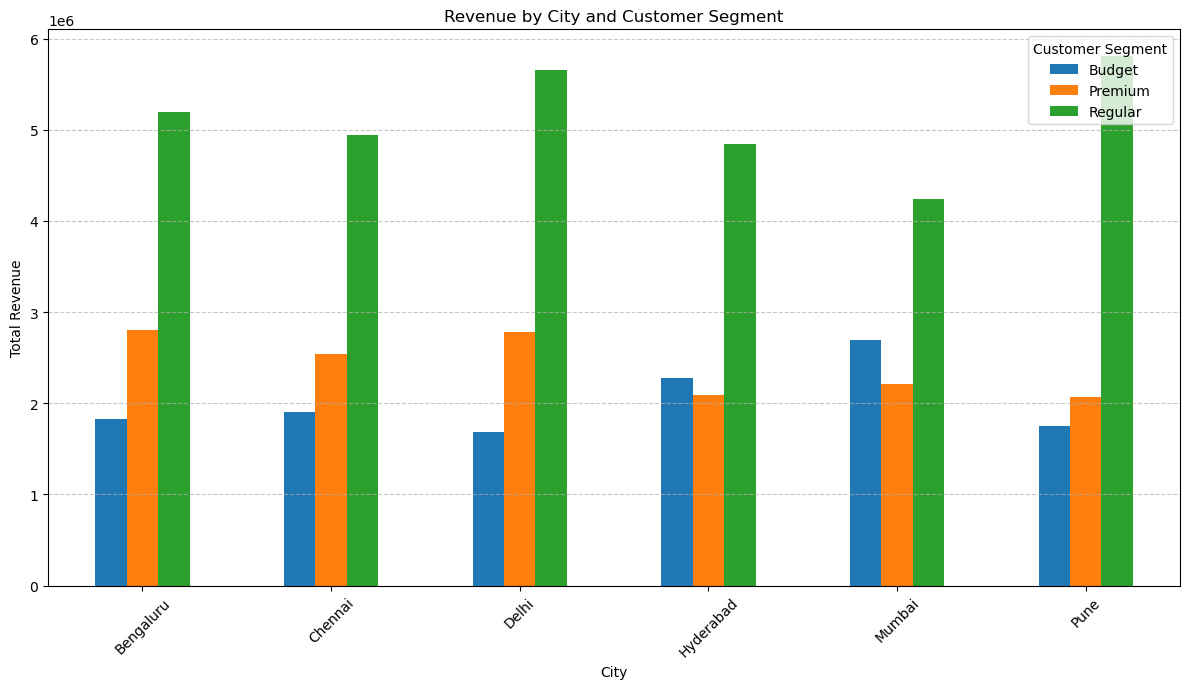

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate Revenue by City and Customer Segment
city_segment_revenue = (
    df.groupby(["City", "Customer_Segment"])["Revenue"]
      .sum()
      .unstack(fill_value=0)
)

# Create grouped bar chart
city_segment_revenue.plot(
    kind="bar",
    figsize=(12, 7)
)

# Title and labels
plt.title("Revenue by City and Customer Segment")
plt.xlabel("City")
plt.ylabel("Total Revenue")

# Rotate city names
plt.xticks(rotation=45)

# Add grid and legend
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Customer Segment")

plt.tight_layout()
plt.show()

#### 15. Plot monthly Revenue and Cost together and shade the area between the two lines to represent Profit.

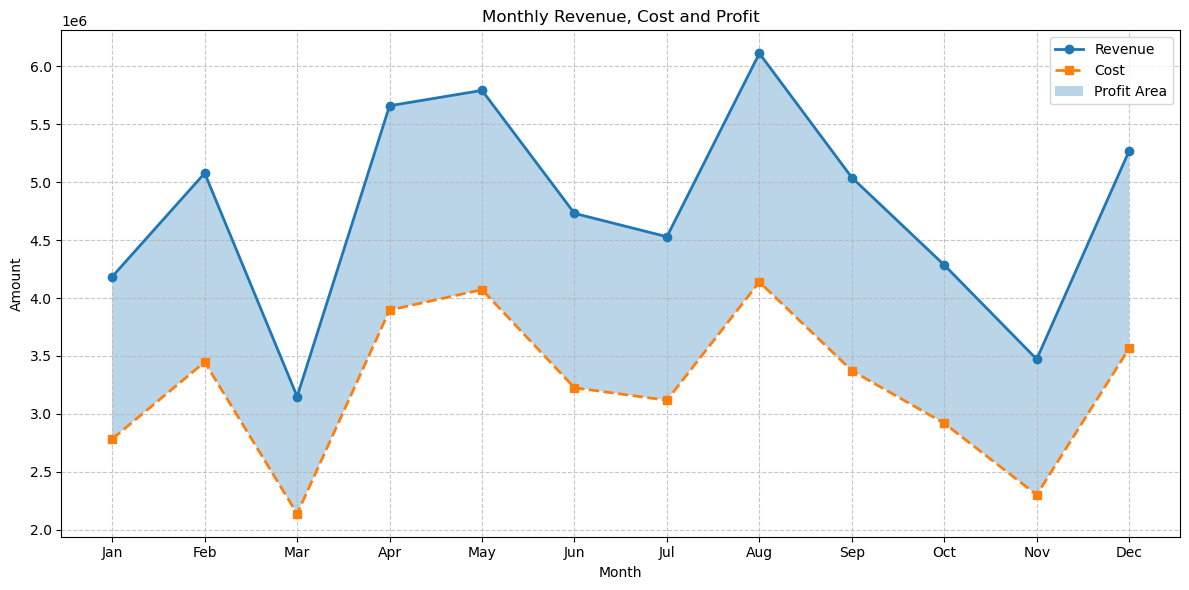

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date into datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month column
df["Month"] = df["Order_Date"].dt.strftime("%b")

# Correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Calculate monthly Revenue and Cost
monthly_data = (
    df.groupby("Month")[["Revenue", "Cost"]]
      .sum()
      .reindex(month_order)
      .dropna()
)

# Create figure
plt.figure(figsize=(12, 6))

# Plot Revenue
plt.plot(
    monthly_data.index,
    monthly_data["Revenue"],
    marker="o",
    linewidth=2,
    label="Revenue"
)

# Plot Cost
plt.plot(
    monthly_data.index,
    monthly_data["Cost"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Cost"
)

# Shade the area between Revenue and Cost
plt.fill_between(
    monthly_data.index,
    monthly_data["Revenue"],
    monthly_data["Cost"],
    alpha=0.3,
    label="Profit Area"
)

# Title and labels
plt.title("Monthly Revenue, Cost and Profit")
plt.xlabel("Month")
plt.ylabel("Amount")

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 16. Find the month with the highest Revenue and annotate that point on the line chart.

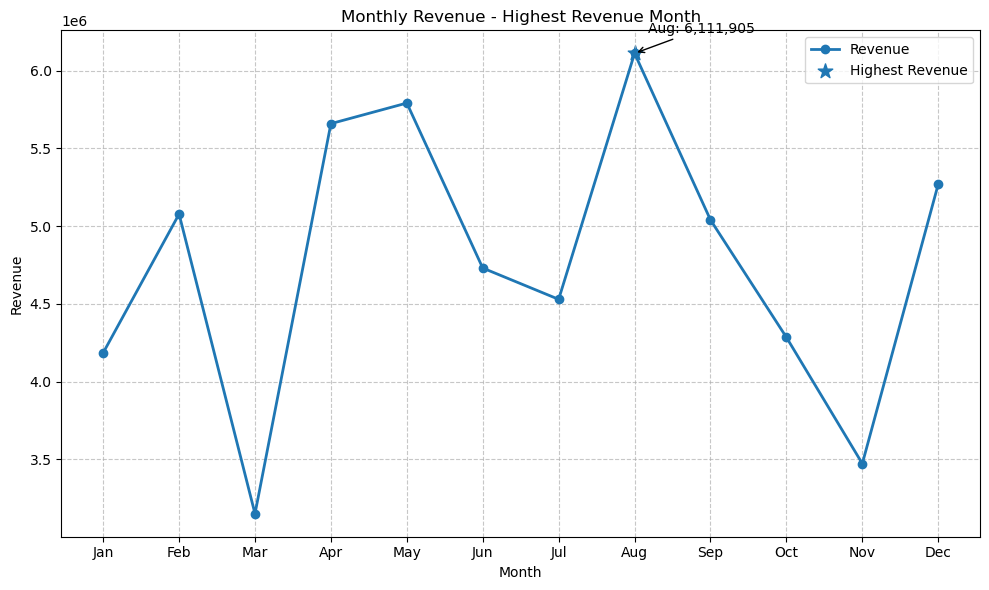

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date into datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month column
df["Month"] = df["Order_Date"].dt.strftime("%b")

# Correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Calculate monthly Revenue
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reindex(month_order)
      .dropna()
)

# Find highest Revenue month
highest_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()

# Create line chart
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    linewidth=2,
    label="Revenue"
)

# Highlight highest point
plt.scatter(
    highest_month,
    highest_revenue,
    s=120,
    marker="*",
    label="Highest Revenue"
)

# Annotate highest Revenue point
plt.annotate(
    f"{highest_month}: {highest_revenue:,.0f}",
    xy=(highest_month, highest_revenue),
    xytext=(10, 15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Title and labels
plt.title("Monthly Revenue - Highest Revenue Month")
plt.xlabel("Month")
plt.ylabel("Revenue")

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 17. Find the month with the lowest Profit and annotate it on the visualization.

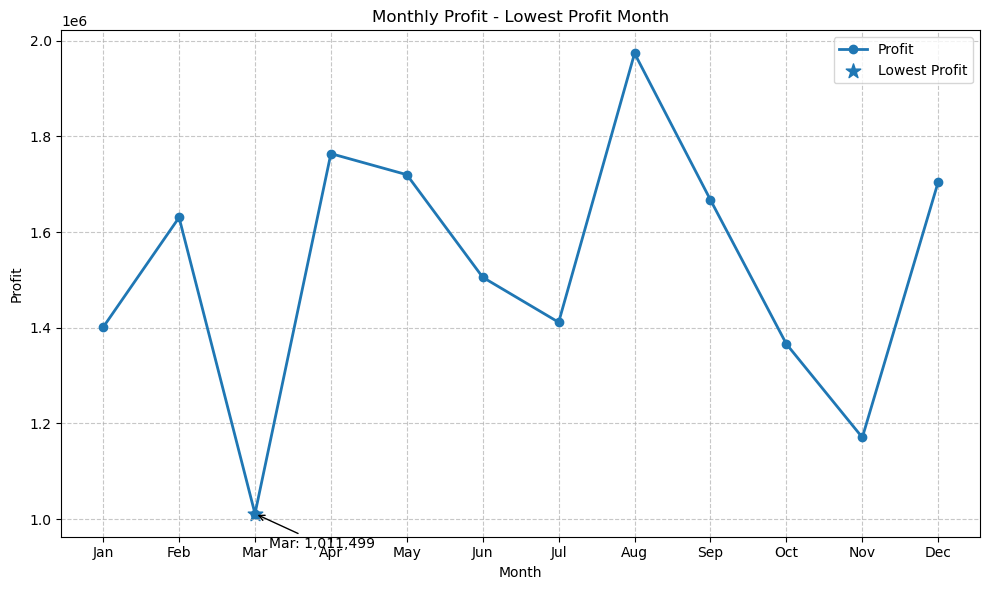

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date into datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month column
df["Month"] = df["Order_Date"].dt.strftime("%b")

# Correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Calculate monthly Profit
monthly_profit = (
    df.groupby("Month")["Profit"]
      .sum()
      .reindex(month_order)
      .dropna()
)

# Find lowest Profit month
lowest_month = monthly_profit.idxmin()
lowest_profit = monthly_profit.min()

# Create line chart
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="o",
    linewidth=2,
    label="Profit"
)

# Highlight lowest point
plt.scatter(
    lowest_month,
    lowest_profit,
    s=120,
    marker="*",
    label="Lowest Profit"
)

# Annotate lowest Profit point
plt.annotate(
    f"{lowest_month}: {lowest_profit:,.0f}",
    xy=(lowest_month, lowest_profit),
    xytext=(10, -25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Title and labels
plt.title("Monthly Profit - Lowest Profit Month")
plt.xlabel("Month")
plt.ylabel("Profit")

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 18. Create a line chart of monthly Revenue and calculate a 3-month moving average. Plot both lines together.

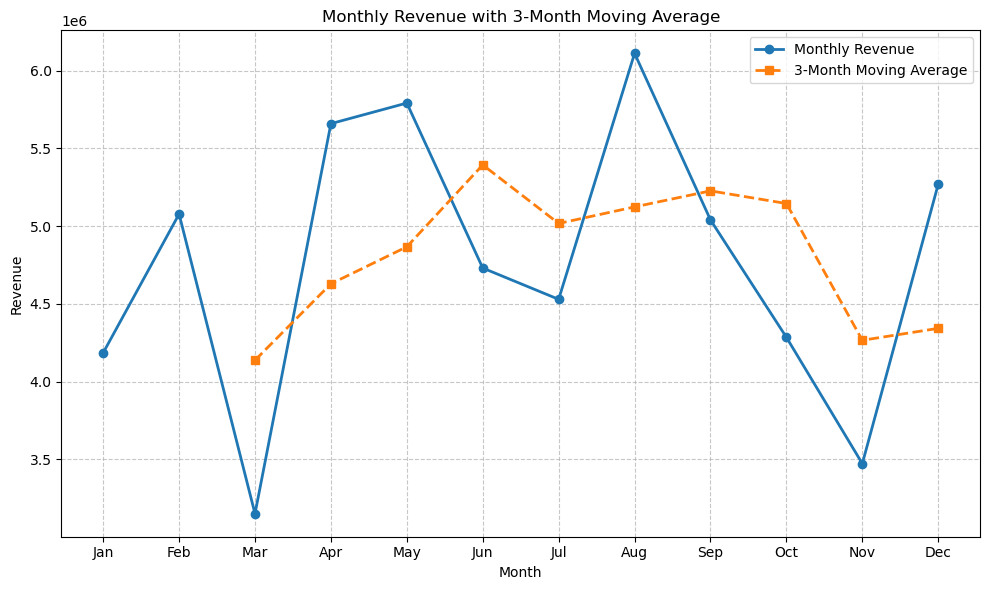

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date into datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month column
df["Month"] = df["Order_Date"].dt.strftime("%b")

# Correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Calculate monthly Revenue
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reindex(month_order)
      .dropna()
)

# Calculate 3-month moving average
moving_average = monthly_revenue.rolling(window=3).mean()

# Create line chart
plt.figure(figsize=(10, 6))

# Monthly Revenue
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    linewidth=2,
    label="Monthly Revenue"
)

# 3-Month Moving Average
plt.plot(
    moving_average.index,
    moving_average.values,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="3-Month Moving Average"
)

# Title and labels
plt.title("Monthly Revenue with 3-Month Moving Average")
plt.xlabel("Month")
plt.ylabel("Revenue")

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 19. Create a scatter plot between Customer_Rating and Revenue. Use Customer_Segment to visually distinguish the points.

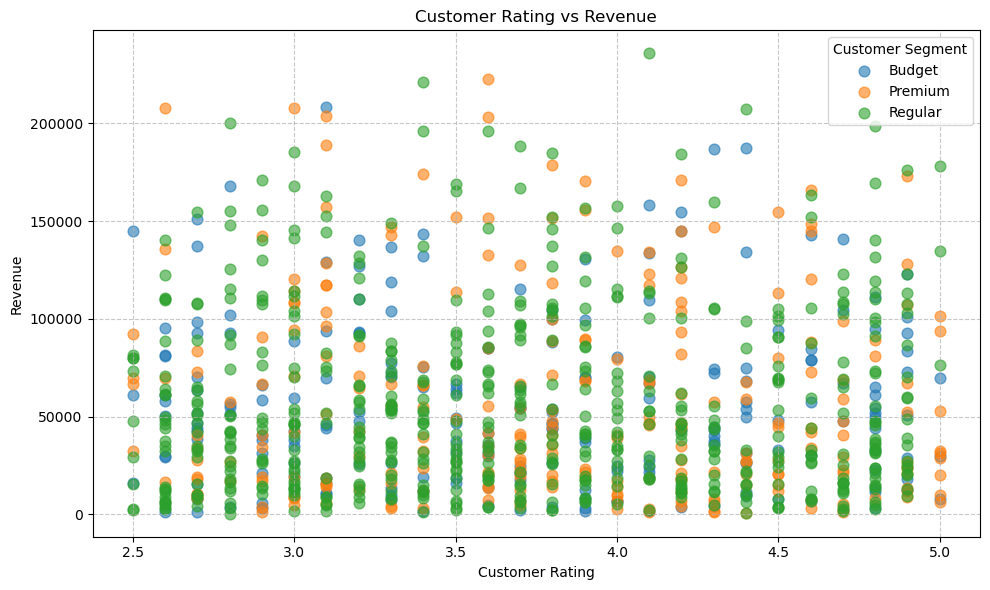

In [22]:
import matplotlib.pyplot as plt

# Get unique customer segments
segments = df["Customer_Segment"].unique()

# Create scatter plot
plt.figure(figsize=(10, 6))

# Plot each customer segment separately
for segment in segments:
    data = df[df["Customer_Segment"] == segment]

    plt.scatter(
        data["Customer_Rating"],
        data["Revenue"],
        s=60,
        alpha=0.6,
        label=segment
    )

# Title and labels
plt.title("Customer Rating vs Revenue")
plt.xlabel("Customer Rating")
plt.ylabel("Revenue")

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Customer Segment")

plt.tight_layout()
plt.show()

#### 20. Create a visualization comparing the average Revenue of Premium, Regular, and Budget customers.

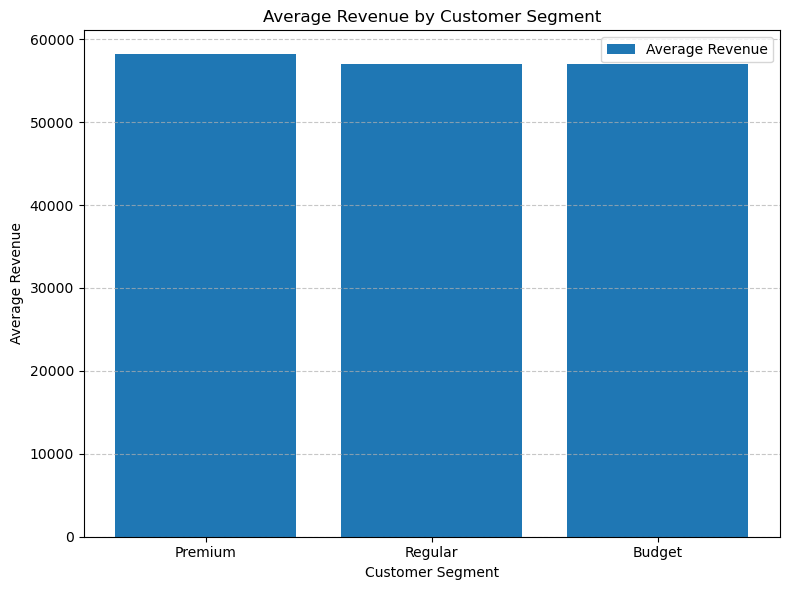

In [23]:
import matplotlib.pyplot as plt

# Calculate average Revenue for each Customer Segment
avg_revenue = (
    df.groupby("Customer_Segment")["Revenue"]
      .mean()
      .reindex(["Premium", "Regular", "Budget"])
)

# Create bar chart
plt.figure(figsize=(8, 6))

plt.bar(
    avg_revenue.index,
    avg_revenue.values,
    label="Average Revenue"
)

# Title and labels
plt.title("Average Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue")

# Grid and legend
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 21. Create a boxplot of Revenue for each Customer_Segment. Compare the distributions visually.

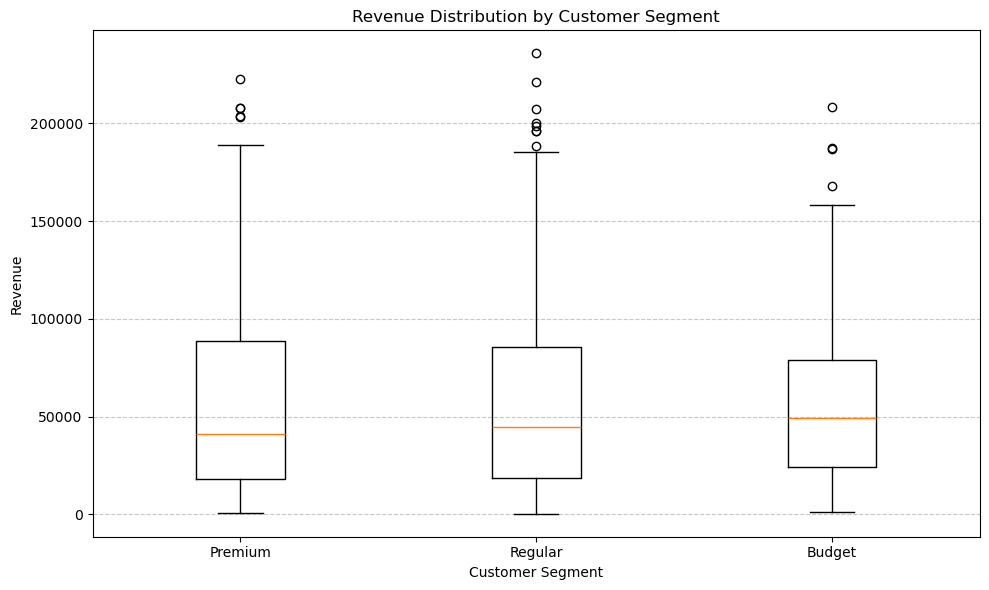

In [35]:
import matplotlib.pyplot as plt

# Get Customer Segments
segments = ["Premium", "Regular", "Budget"]

# Create Revenue data for each segment
revenue_data = [
    df[df["Customer_Segment"] == segment]["Revenue"]
    for segment in segments
]

# Create boxplot
plt.figure(figsize=(10, 6))

plt.boxplot(
    revenue_data,
    tick_labels=segments
)

# Title and labels
plt.title("Revenue Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

# Add grid
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

#### 22. Create boxplots of Revenue for each Product_Category and identify which category has the largest spread.

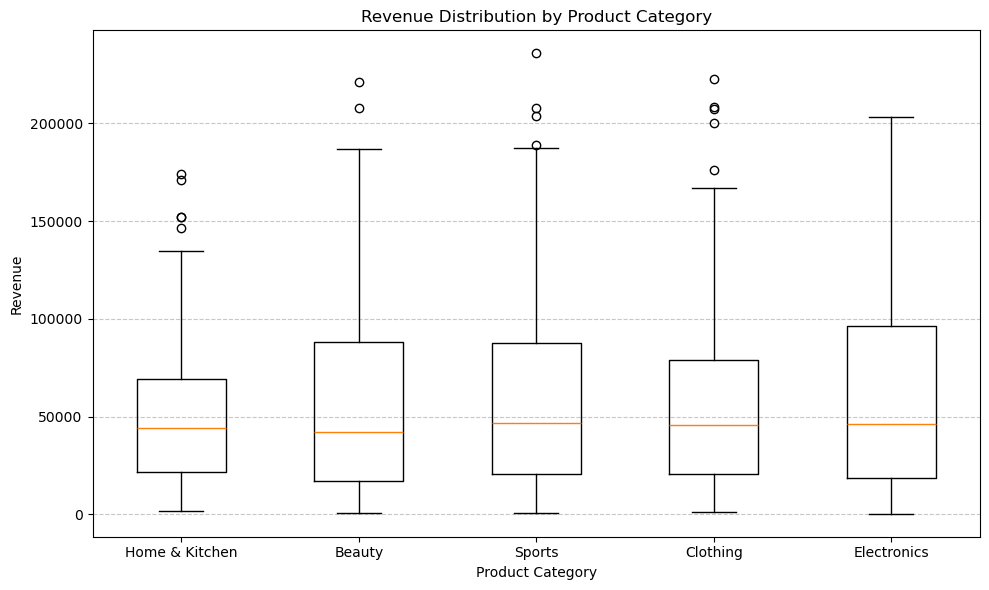

In [28]:
import matplotlib.pyplot as plt

# Get Product Categories
categories = df["Product_Category"].unique()

# Create Revenue data for each category
revenue_data = [
    df[df["Product_Category"] == category]["Revenue"]
    for category in categories
]

# Create boxplot
plt.figure(figsize=(10, 6))

plt.boxplot(
    revenue_data,
    tick_labels=categories
)

# Title and labels
plt.title("Revenue Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

#### 23. Create a 3×2 Matplotlib dashboard containing:
#### o Monthly revenue
#### o Monthly profit
#### o Category revenue
#### o City profit
#### o Customer-age distribution
#### o Discount vs profit

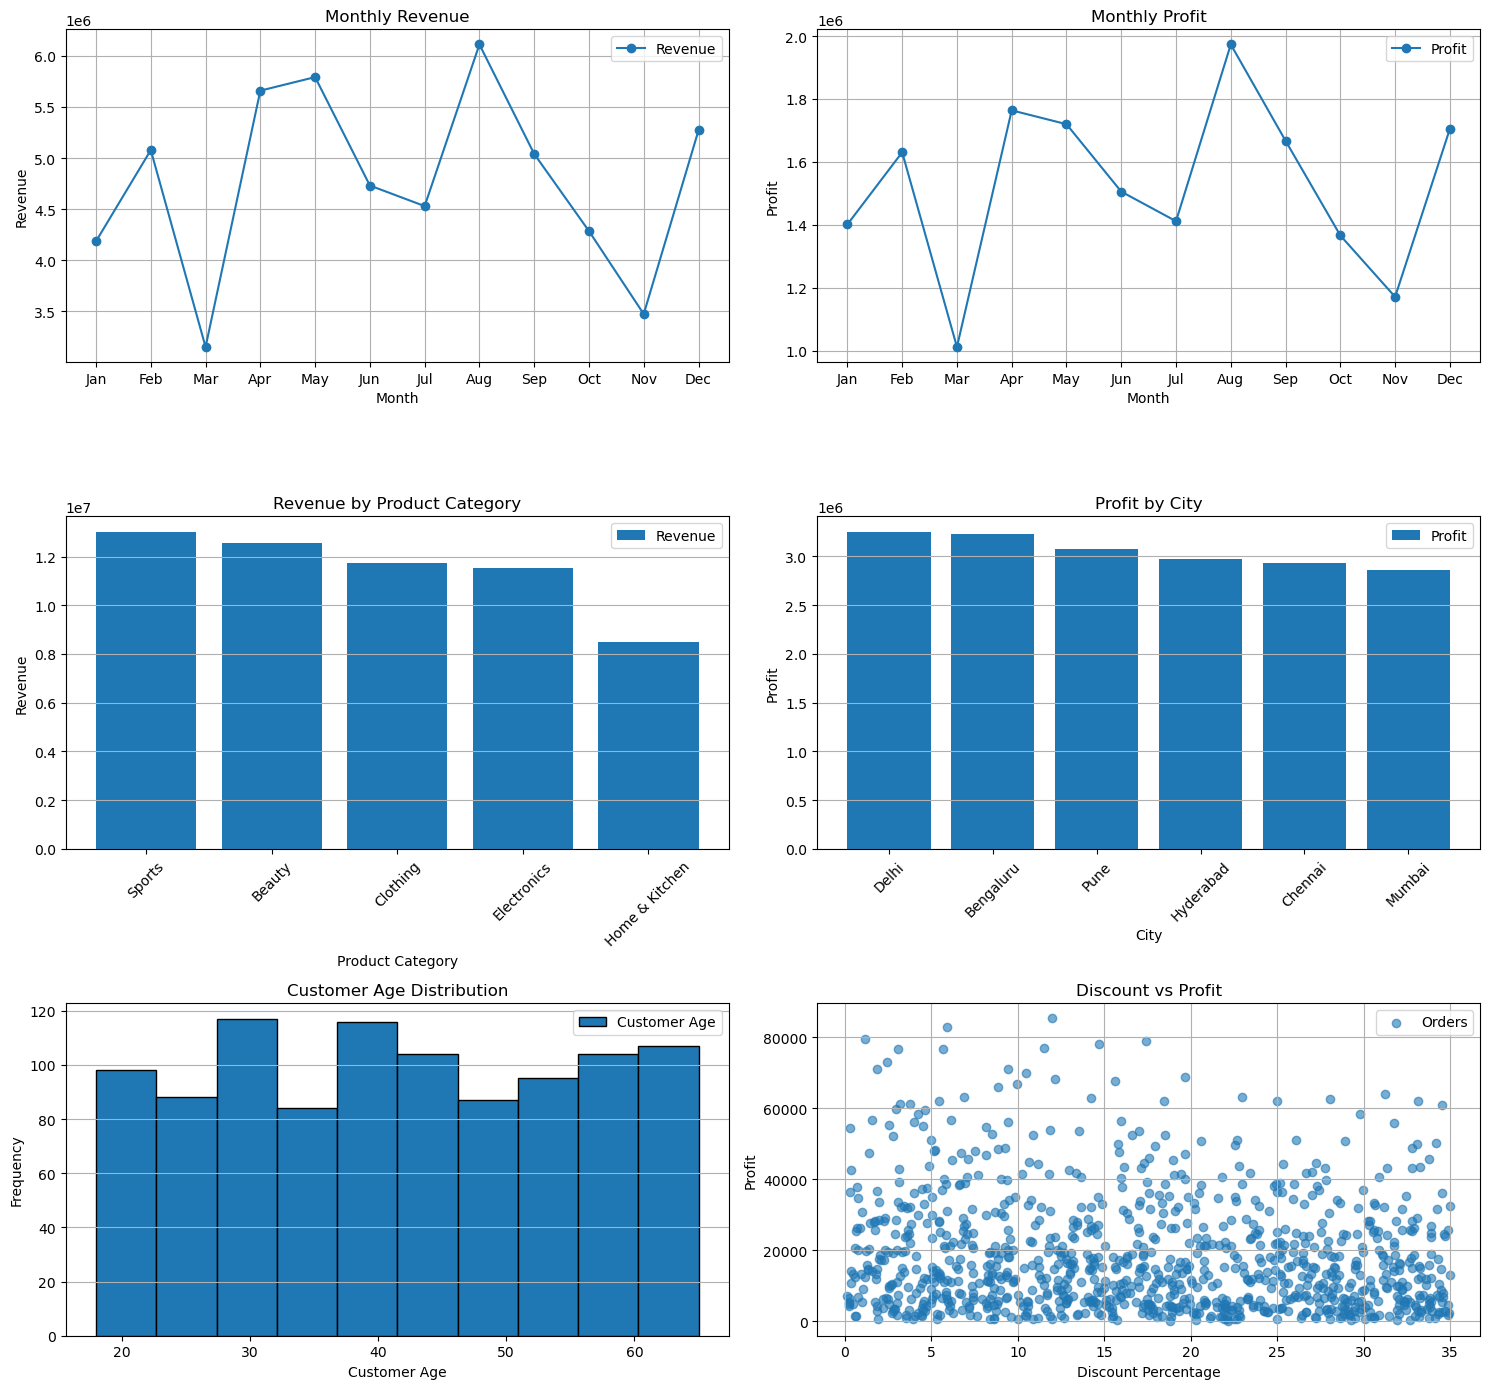

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month column
df["Month"] = df["Order_Date"].dt.strftime("%b")

# Correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Monthly Revenue
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reindex(month_order)
      .dropna()
)

# Monthly Profit
monthly_profit = (
    df.groupby("Month")["Profit"]
      .sum()
      .reindex(month_order)
      .dropna()
)

# Revenue by Product Category
category_revenue = (
    df.groupby("Product_Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

# Profit by City
city_profit = (
    df.groupby("City")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

# Create 3 × 2 dashboard
fig, axes = plt.subplots(3, 2, figsize=(15, 14))

# -------------------------------
# 1. Monthly Revenue
# -------------------------------
axes[0, 0].plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    label="Revenue"
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].grid(True)
axes[0, 0].legend()

# -------------------------------
# 2. Monthly Profit
# -------------------------------
axes[0, 1].plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="o",
    label="Profit"
)

axes[0, 1].set_title("Monthly Profit")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].grid(True)
axes[0, 1].legend()

# -------------------------------
# 3. Category Revenue
# -------------------------------
axes[1, 0].bar(
    category_revenue.index,
    category_revenue.values,
    label="Revenue"
)

axes[1, 0].set_title("Revenue by Product Category")
axes[1, 0].set_xlabel("Product Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(axis="y")
axes[1, 0].legend()

# -------------------------------
# 4. City Profit
# -------------------------------
axes[1, 1].bar(
    city_profit.index,
    city_profit.values,
    label="Profit"
)

axes[1, 1].set_title("Profit by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y")
axes[1, 1].legend()

# -------------------------------
# 5. Customer Age Distribution
# -------------------------------
axes[2, 0].hist(
    df["Customer_Age"],
    bins=10,
    edgecolor="black",
    label="Customer Age"
)

axes[2, 0].set_title("Customer Age Distribution")
axes[2, 0].set_xlabel("Customer Age")
axes[2, 0].set_ylabel("Frequency")
axes[2, 0].grid(axis="y")
axes[2, 0].legend()

# -------------------------------
# 6. Discount vs Profit
# -------------------------------
axes[2, 1].scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6,
    label="Orders"
)

axes[2, 1].set_title("Discount vs Profit")
axes[2, 1].set_xlabel("Discount Percentage")
axes[2, 1].set_ylabel("Profit")
axes[2, 1].grid(True)
axes[2, 1].legend()

# Adjust layout
plt.tight_layout()

# Display dashboard
plt.show()

#### 24. Create a chart showing Revenue vs Discount_Pct and use marker size to represent Units_Sold.

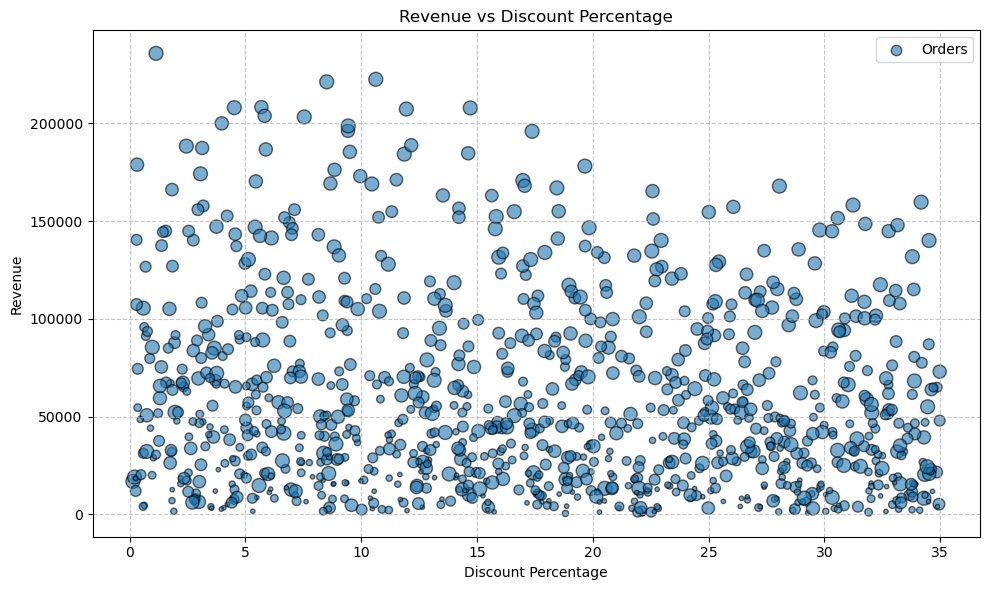

In [30]:
import matplotlib.pyplot as plt

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount_Pct"],
    df["Revenue"],
    s=df["Units_Sold"] * 10,
    alpha=0.6,
    edgecolor="black",
    label="Orders"
)

# Title and labels
plt.title("Revenue vs Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Revenue")

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 25. Identify the top 10 highest-revenue orders and visualize them using a horizontal bar chart. Display the Order_ID beside each bar.

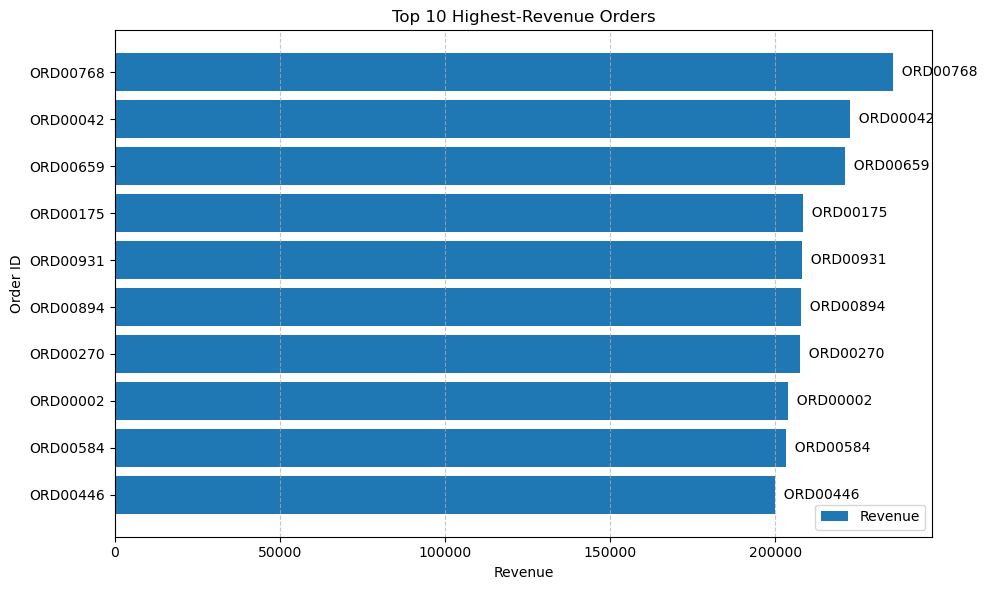

In [31]:
import matplotlib.pyplot as plt

# Find top 10 orders based on Revenue
top_10 = (
    df.nlargest(10, "Revenue")
      .sort_values("Revenue")
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Order_ID"].astype(str),
    top_10["Revenue"],
    label="Revenue"
)

# Add Order_ID beside each bar
for i, (order_id, revenue) in enumerate(
    zip(top_10["Order_ID"], top_10["Revenue"])
):
    plt.text(
        revenue,
        i,
        f"  {order_id}",
        va="center"
    )

# Title and labels
plt.title("Top 10 Highest-Revenue Orders")
plt.xlabel("Revenue")
plt.ylabel("Order ID")

# Grid and legend
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

#### 26. Create a visualization showing monthly Orders and Revenue using two Y-axes. Use the first Y-axis for order count and the second for revenue.

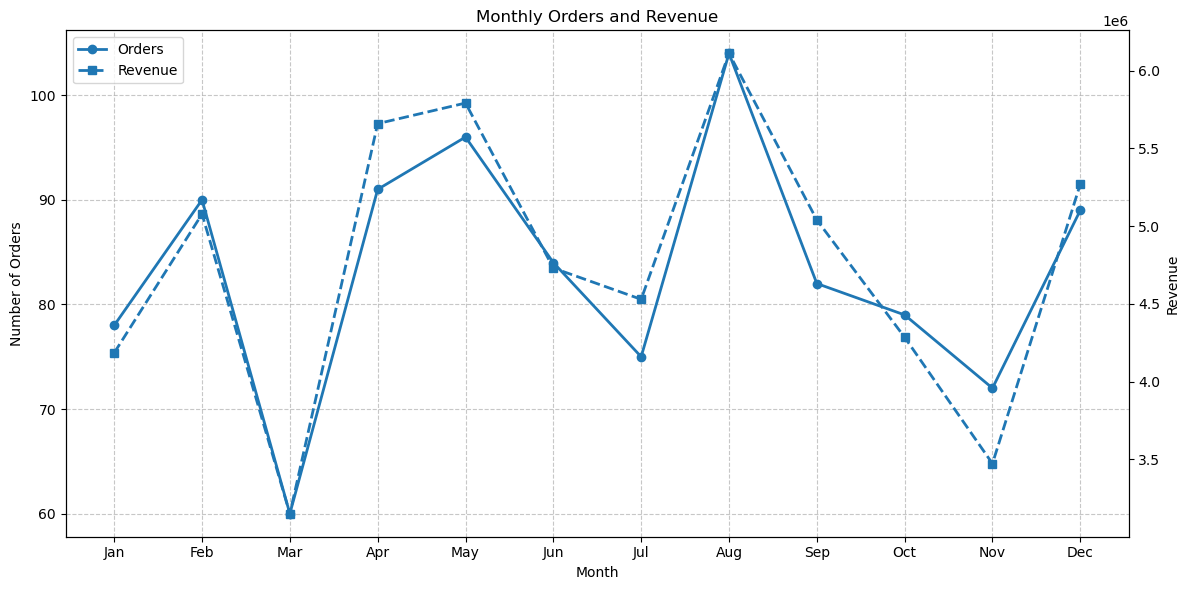

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date into datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month column
df["Month"] = df["Order_Date"].dt.strftime("%b")

# Correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Calculate monthly Orders and Revenue
monthly_orders = (
    df.groupby("Month")["Order_ID"]
      .count()
      .reindex(month_order)
      .dropna()
)

monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reindex(month_order)
      .dropna()
)

# Create first Y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Orders on first Y-axis
ax1.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o",
    linewidth=2,
    label="Orders"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Orders")
ax1.grid(True, linestyle="--", alpha=0.7)

# Create second Y-axis
ax2 = ax1.twinx()

# Plot Revenue on second Y-axis
ax2.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Revenue"
)

ax2.set_ylabel("Revenue")

# Title
plt.title("Monthly Orders and Revenue")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### 27. Create a heatmap-style visualization using Matplotlib only for the correlation matrix of:
##### Customer_Age, Units_Sold, Unit_Price, Discount_Pct, Revenue, Cost, and Profit.

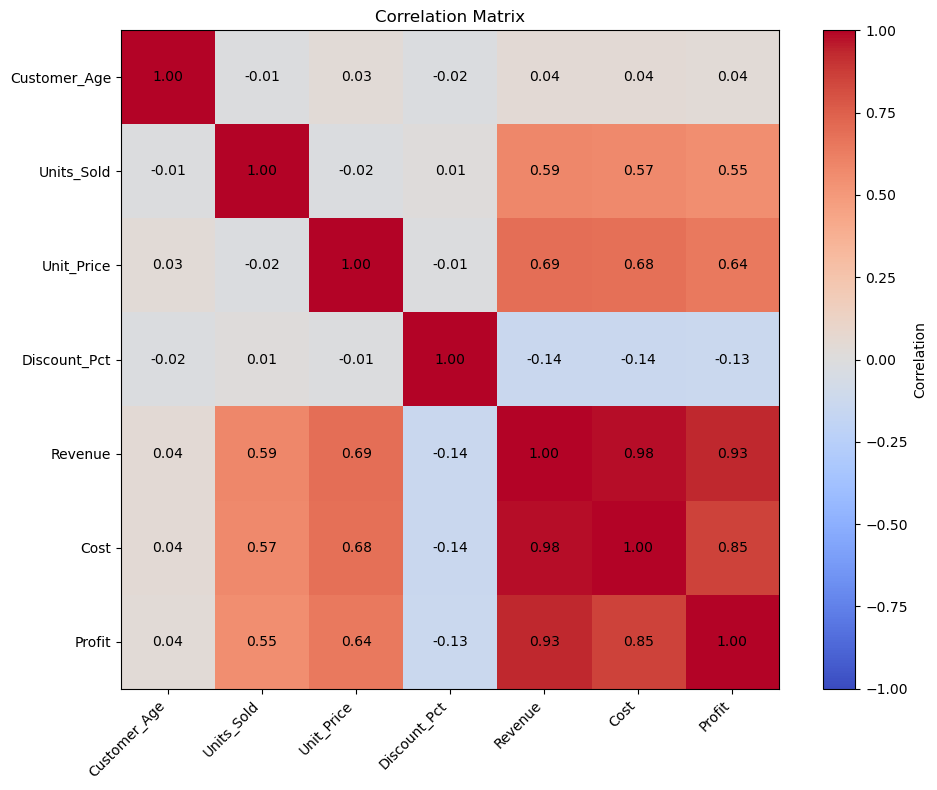

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Select required columns
columns = [
    "Customer_Age",
    "Units_Sold",
    "Unit_Price",
    "Discount_Pct",
    "Revenue",
    "Cost",
    "Profit"
]

# Calculate correlation matrix
corr = df[columns].corr()

# Create heatmap using Matplotlib
plt.figure(figsize=(10, 8))

plt.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

# Add colorbar
plt.colorbar(label="Correlation")

# Set axis labels
plt.xticks(
    range(len(columns)),
    columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(columns)),
    columns
)

# Display correlation values inside cells
for i in range(len(columns)):
    for j in range(len(columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

# Title
plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

#### 28. Create a dashboard comparing City × Product_Category Revenue. Use a suitable visualization to show which combinations generate the highest revenue.

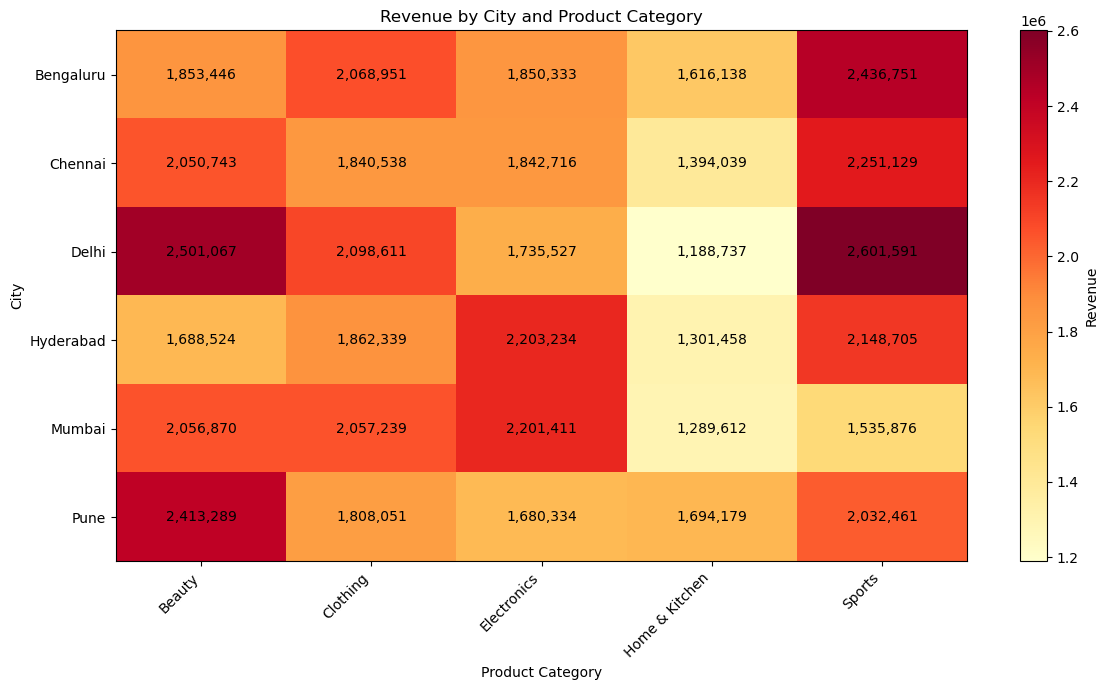

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate Revenue by City and Product Category
city_category_revenue = (
    df.groupby(["City", "Product_Category"])["Revenue"]
      .sum()
      .unstack(fill_value=0)
)

# Create heatmap-style visualization
plt.figure(figsize=(12, 7))

plt.imshow(
    city_category_revenue,
    cmap="YlOrRd",
    aspect="auto"
)

# Add colorbar
plt.colorbar(label="Revenue")

# Set labels
plt.xticks(
    range(len(city_category_revenue.columns)),
    city_category_revenue.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(city_category_revenue.index)),
    city_category_revenue.index
)

# Display Revenue values inside cells
for i in range(len(city_category_revenue.index)):
    for j in range(len(city_category_revenue.columns)):
        value = city_category_revenue.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:,.0f}",
            ha="center",
            va="center"
        )

# Title
plt.title("Revenue by City and Product Category")

plt.xlabel("Product Category")
plt.ylabel("City")

plt.tight_layout()
plt.show()